In [6]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [7]:
df = pd.read_csv('/content/ecommerce.csv.zip', encoding='ISO-8859-1')
print("Dataset shape (Rows, Columns):", df.shape)
df.head()

Dataset shape (Rows, Columns): (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
print("--- Dataset Columns ---")
print(df.columns)
print("\n--- Missing Value Counts ---")
print(df.isnull().sum())

--- Dataset Columns ---
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

--- Missing Value Counts ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [9]:
duplicate_count = df.duplicated().sum()
print(f"Number of identical duplicate rows: {duplicate_count}")
duplicate_percentage = (duplicate_count / len(df)) * 100
print(f"Percentage of duplicate data: {duplicate_percentage:.2f}%")

Number of identical duplicate rows: 5268
Percentage of duplicate data: 0.97%


In [10]:
df['Description'] = df['Description'].fillna('Unknown Item Description')
df['CustomerID'] = df['CustomerID'].astype(str).replace('nan', 'Guest Customer')
df['CustomerID'] = df['CustomerID'].fillna('Guest Customer')
print("--- Missing Values After Cleaning ---")
print(df.isnull().sum())

--- Missing Values After Cleaning ---
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [11]:
print("Duplicates found before cleaning:", df.duplicated().sum())
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print("Duplicates remaining after cleaning:", df.duplicated().sum())

Duplicates found before cleaning: 5268
Duplicates remaining after cleaning: 0


In [12]:
df['Description'] = df['Description'].fillna('Unknown Item Description')
df['CustomerID'] = df['CustomerID'].astype(str).replace('nan', 'Guest Customer')
df['CustomerID'] = df['CustomerID'].fillna('Guest Customer')
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print("Remaining Missing Values:\n", df.isnull().sum())
print("\nRemaining Duplicates:", df.duplicated().sum())

Remaining Missing Values:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Remaining Duplicates: 0


In [13]:
print("Rows with negative Quantity:", (df['Quantity'] < 0).sum())
print("Rows with negative UnitPrice:", (df['UnitPrice'] < 0).sum())
print("\nFirst few date records look like:")
print(df['InvoiceDate'].head())

Rows with negative Quantity: 10587
Rows with negative UnitPrice: 2

First few date records look like:
0    12/1/2010 8:26
1    12/1/2010 8:26
2    12/1/2010 8:26
3    12/1/2010 8:26
4    12/1/2010 8:26
Name: InvoiceDate, dtype: object


In [14]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] >= 0)]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.date
print("--- Validation Audit ---")
print("Remaining negative Quantities:", (df['Quantity'] < 0).sum())
print("Remaining negative UnitPrices:", (df['UnitPrice'] < 0).sum())
print("\nNew Clean Date Format sample:")
print(df['InvoiceDate'].head())
print("\nFinal clean dataset shape:", df.shape)

--- Validation Audit ---
Remaining negative Quantities: 0
Remaining negative UnitPrices: 0

New Clean Date Format sample:
0    2010-12-01
1    2010-12-01
2    2010-12-01
3    2010-12-01
4    2010-12-01
Name: InvoiceDate, dtype: object

Final clean dataset shape: (526052, 8)


In [15]:
df.to_csv('cleaned_ecommerce.csv', index=False)
print("File successfully saved as 'cleaned_ecommerce.csv'!")

File successfully saved as 'cleaned_ecommerce.csv'!


In [23]:
import zipfile

# Define the file names
csv_file_path = 'cleaned_ecommerce.csv'
zip_file_path = 'cleaned_ecommerce.zip'

# Create the zip archive
with zipfile.ZipFile(zip_file_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(csv_file_path)

print(f"Successfully created {zip_file_path}")

Successfully created cleaned_ecommerce.zip


In [24]:
from google.colab import files
files.download('cleaned_ecommerce.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

total_revenue = df['TotalAmount'].sum()
total_orders = df['InvoiceNo'].nunique() # Counts only unique transaction numbers
average_order_value = total_revenue / total_orders
total_units_sold = df['Quantity'].sum()

top_selling_items = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
top_revenue_items = df.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False)

top_product_by_demand = top_selling_items.index[0]
top_product_by_revenue = top_revenue_items.index[0]

print("====================================================")
print("             WEINTERN SALES KPI SUMMARY             ")
print("====================================================")
print(f"Total Revenue            : ${total_revenue:,.2f}")
print(f"Total Orders             : {total_orders:,}")
print(f"Average Order Value (AOV): ${average_order_value:,.2f}")
print(f"Total Units Sold         : {total_units_sold:,}")
print(f"Top Product (by Demand)  : {top_product_by_demand}")
print(f"Top Product (by Revenue) : {top_product_by_revenue}")
print("====================================================")

             WEINTERN SALES KPI SUMMARY             
Total Revenue            : $10,642,110.80
Total Orders             : 20,726
Average Order Value (AOV): $513.47
Total Units Sold         : 5,645,017
Top Product (by Demand)  : PAPER CRAFT , LITTLE BIRDIE
Top Product (by Revenue) : DOTCOM POSTAGE


In [17]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_analysis = df.groupby('Month').agg(
    Monthly_Revenue=('TotalAmount', 'sum'),
    Monthly_Orders=('InvoiceNo', 'nunique')
).reset_index()

monthly_analysis['Month'] = monthly_analysis['Month'].astype(str)

print("=========================================")
print("          MONTH-BY-MONTH TRENDS          ")
print("=========================================")
print(monthly_analysis)

          MONTH-BY-MONTH TRENDS          
      Month  Monthly_Revenue  Monthly_Orders
0   2010-12       821452.730            1629
1   2011-01       689811.610            1120
2   2011-02       522545.560            1126
3   2011-03       716215.260            1531
4   2011-04       536968.491            1318
5   2011-05       769296.610            1731
6   2011-06       760547.010            1576
7   2011-07       718076.121            1540
8   2011-08       757841.380            1407
9   2011-09      1056435.192            1896
10  2011-10      1151263.730            2129
11  2011-11      1503866.780            2884
12  2011-12       637790.330             839


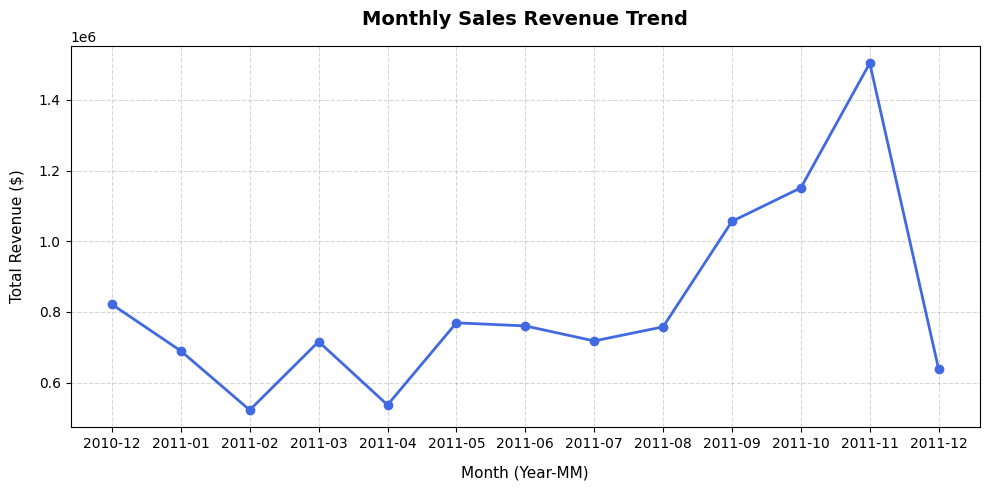

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_analysis['Month'], monthly_analysis['Monthly_Revenue'],
         marker='o', color='royalblue', linewidth=2, label='Revenue')
plt.title('Monthly Sales Revenue Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month (Year-MM)', fontsize=11, labelpad=10)
plt.ylabel('Total Revenue ($)', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5) # Adds a clean background grid
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=300)
plt.show()

In [19]:
country_analysis = df.groupby('Country').agg(
    Revenue=('TotalAmount', 'sum'),
    Total_Orders=('InvoiceNo', 'nunique')
).sort_values(ascending=False, by='Revenue').reset_index()

df['Customer_Type'] = df['CustomerID'].apply(lambda x: 'Guest' if x == 'Guest Customer' else 'Registered')

customer_analysis = df.groupby('Customer_Type').agg(
    Revenue=('TotalAmount', 'sum'),
    Total_Orders=('InvoiceNo', 'nunique'),
    Units_Bought=('Quantity', 'sum')
).reset_index()

print("=========================================")
print("          TOP 5 COUNTRIES BY REVENUE     ")
print("=========================================")
print(country_analysis.head(5))

print("\n=========================================")
print("          CUSTOMER SEGMENT ANALYSIS      ")
print("=========================================")
print(customer_analysis)

          TOP 5 COUNTRIES BY REVENUE     
          Country      Revenue  Total_Orders
0  United Kingdom  9001744.094         18784
1     Netherlands   285446.340            95
2            EIRE   283140.520           288
3         Germany   228678.400           457
4          France   209625.370           392

          CUSTOMER SEGMENT ANALYSIS      
  Customer_Type      Revenue  Total_Orders  Units_Bought
0         Guest  1754901.910          2190        479131
1    Registered  8887208.894         18536       5165886


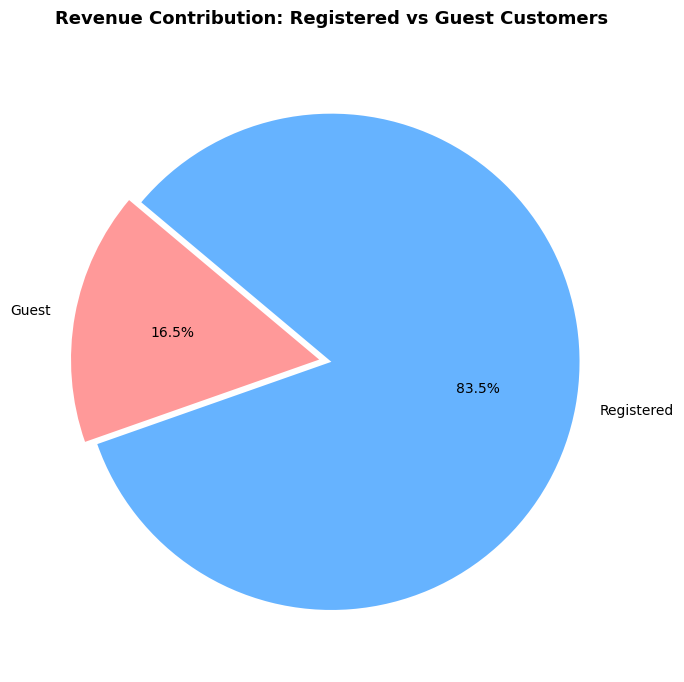

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 7))

plt.pie(customer_analysis['Revenue'],
        labels=customer_analysis['Customer_Type'],
        autopct='%1.1f%%',
        startangle=140,
        colors=['#ff9999','#66b3ff'],
        explode=(0.05, 0))
plt.title('Revenue Contribution: Registered vs Guest Customers', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('customer_revenue_share.png', dpi=300)
plt.show()

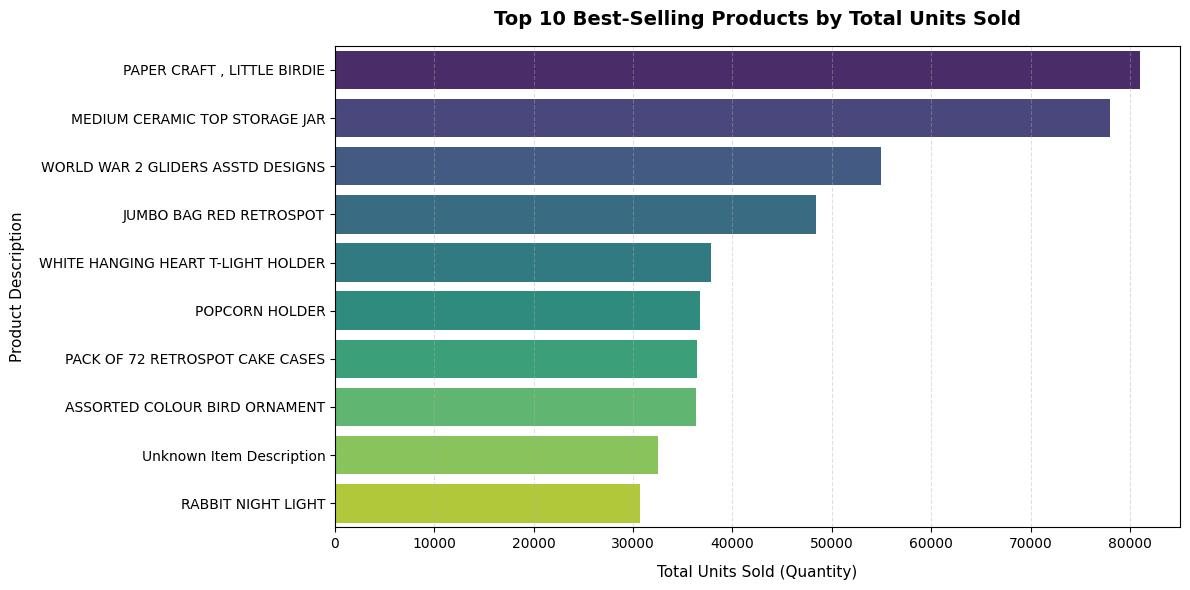

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

top_10_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Quantity', y='Description', data=top_10_products, hue='Description', palette='viridis', legend=False)
plt.title('Top 10 Best-Selling Products by Total Units Sold', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Units Sold (Quantity)', fontsize=11, labelpad=10)
plt.ylabel('Product Description', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.4, axis='x')
plt.tight_layout()
plt.savefig('top_10_products_bar.png', dpi=300)
plt.show()

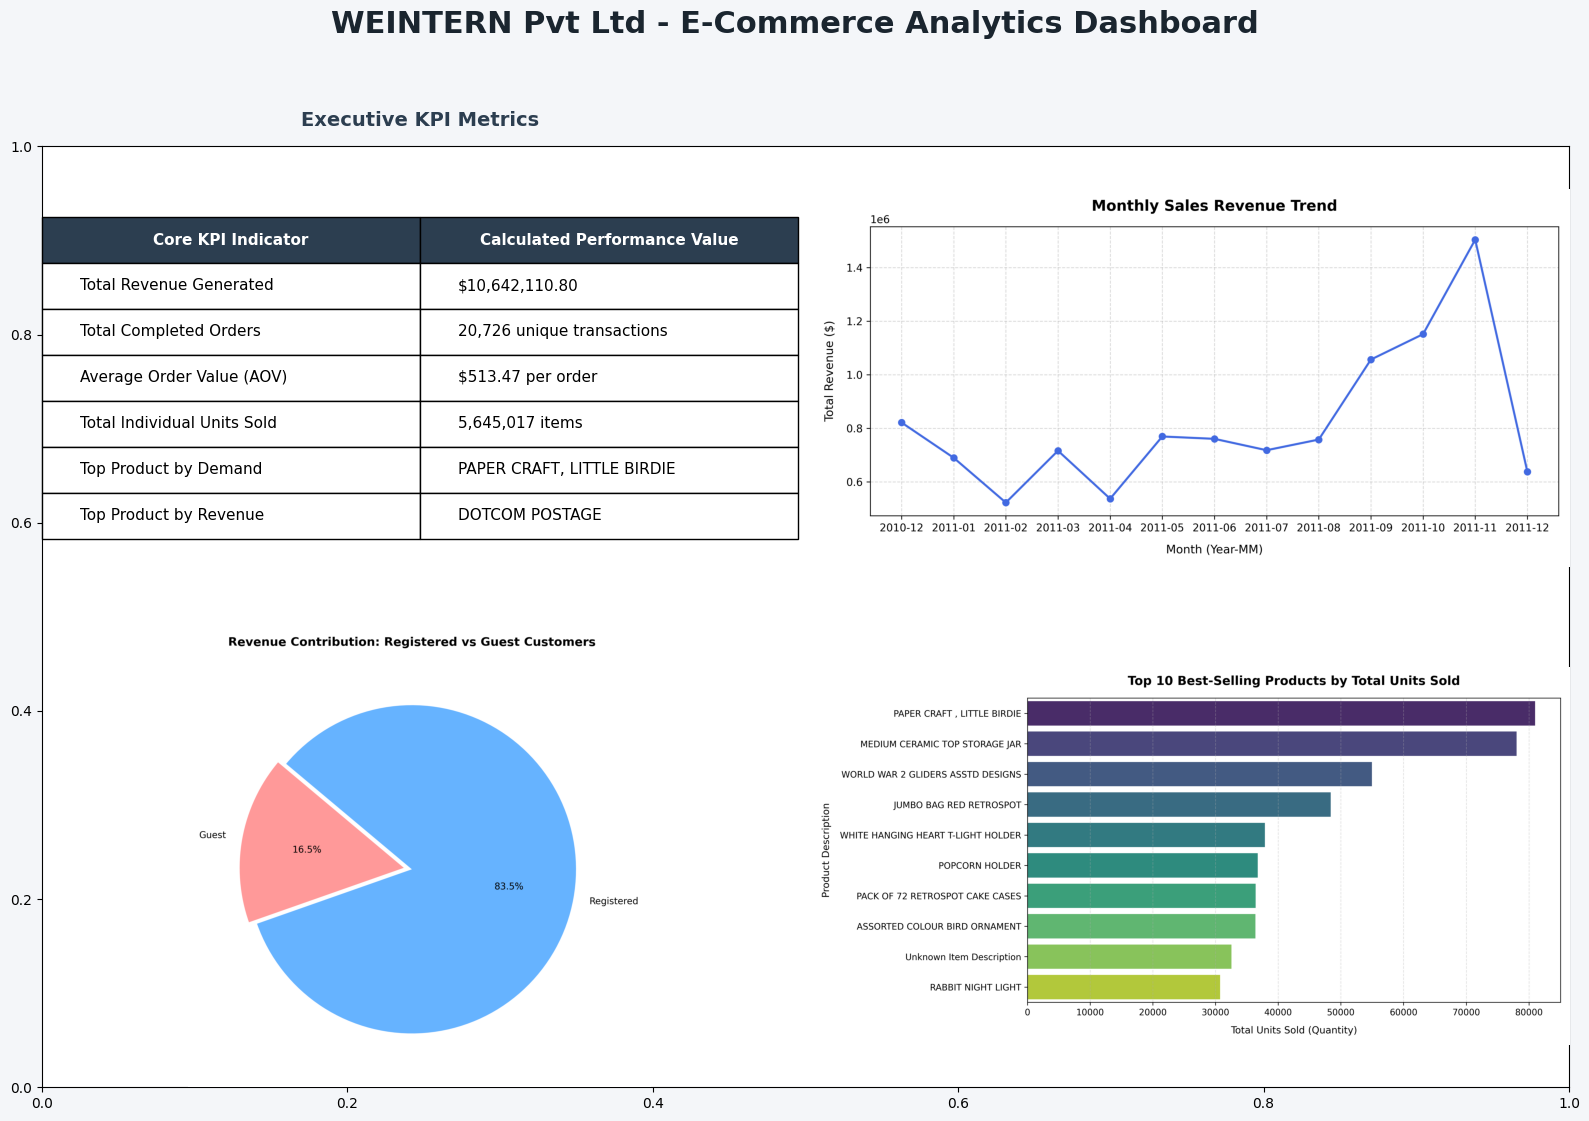

🎉 Success! Your final clean dashboard mockup has been generated.


In [22]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axs = plt.subplots(figsize=(16, 12), facecolor='#f4f6f9')
plt.suptitle("WEINTERN Pvt Ltd - E-Commerce Analytics Dashboard", fontsize=22, fontweight='bold', color='#1a252f', y=0.96)

ax1 = plt.subplot2grid((2, 2), (0, 0))
ax1.set_facecolor('white')
kpi_data = [
    ["Total Revenue Generated", "$10,642,110.80"],
    ["Total Completed Orders", "20,726 unique transactions"],
    ["Average Order Value (AOV)", "$513.47 per order"],
    ["Total Individual Units Sold", "5,645,017 items"],
    ["Top Product by Demand", "PAPER CRAFT, LITTLE BIRDIE"],
    ["Top Product by Revenue", "DOTCOM POSTAGE"]
]
table = ax1.table(cellText=kpi_data, colLabels=["Core KPI Indicator", "Calculated Performance Value"],
                  loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
ax1.axis('off')
ax1.set_title("Executive KPI Metrics", fontsize=14, fontweight='bold', pad=15, color='#2c3e50')

ax2 = plt.subplot2grid((2, 2), (0, 1))
img_trend = mpimg.imread('monthly_sales_trend.png')
ax2.imshow(img_trend)
ax2.axis('off')

ax3 = plt.subplot2grid((2, 2), (1, 0))
img_pie = mpimg.imread('customer_revenue_share.png')
ax3.imshow(img_pie)
ax3.axis('off')

ax4 = plt.subplot2grid((2, 2), (1, 1))
img_bar = mpimg.imread('top_10_products_bar.png')
ax4.imshow(img_bar)
ax4.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('dashboard_mockup.png', dpi=300)
plt.show()
print("🎉 Success! Your final clean dashboard mockup has been generated.")